In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

# Data Collection & Analysis

In [2]:
 # loading the data from csv file to a Pandas DataFrame
df=pd.read_csv("datasets_13720_18513_insurance(1).csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## Domain Analysis

The data that we have has 7 different variables. Each of them is stated below.

Age: Insurance contractor's age

Sex: Insurance contractor's gender, [female, male]

BMI: Body mass index, providing an understanding of body, weights that are relatively high or low relative to height, objective index of body weight (kg/m^2) using the ratio of height to weight, ideally 18.5 to 24.9

Children: Number of children covered by health insurance / Number of dependents

Smoker: Smoking, [yes, no]

Region: The beneficiary's residential area [northeast, southeast, southwest, northwest]

Charges: Individual medical costs billed by health insurance.

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.shape

(1338, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


Categorical Features:

1)Sex

2)Smoker

3)Region

In [6]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
# statistical Measures of the dataset
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
df.duplicated().sum()

1

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.value_counts("sex")

sex
male      675
female    662
dtype: int64

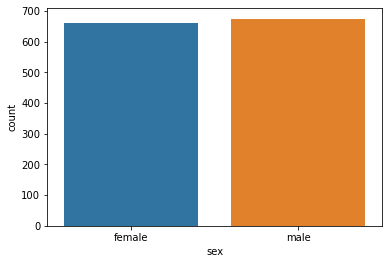

In [11]:
sns.countplot(x= "sex", data = df)
plt.show()

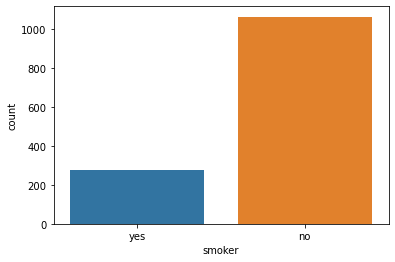

In [12]:
sns.countplot(x= "smoker", data = df)
plt.show()

In [13]:
df.smoker.value_counts()

no     1063
yes     274
Name: smoker, dtype: int64

In [14]:
df.region.value_counts()

southeast    364
southwest    325
northwest    324
northeast    324
Name: region, dtype: int64

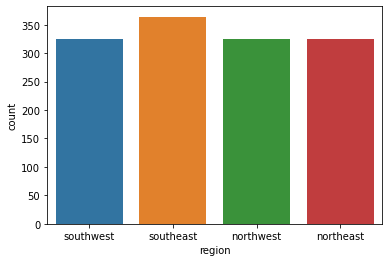

In [15]:
sns.countplot(x= "region", data=df)
plt.show()

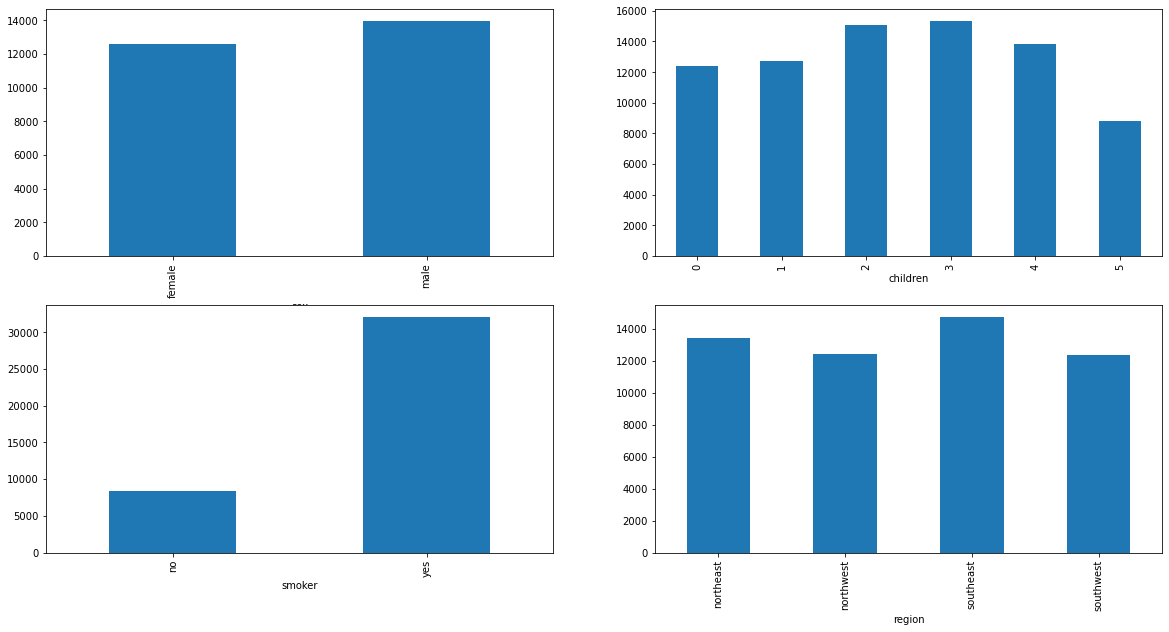

In [16]:
features=['sex','children','smoker','region']
plt.subplots(figsize=(20,10))
for i,  col in enumerate(features):
    plt.subplot(2,2,i+1)
    df.groupby(col).mean()['charges'].plot.bar()
plt.show()

Observation:-
Charges are on the higher side for males as compared to females but the difference is not that much.
Premium charged from the smoker is around thrice that which is charged from non-smokers.
Charges are approximately the same in the given four regions.

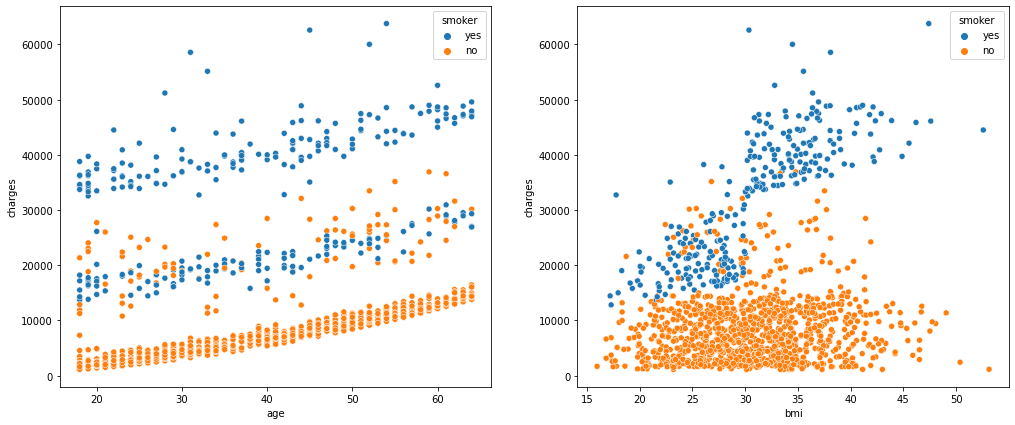

In [17]:
features = ['age', 'bmi']
plt.subplots(figsize=(17, 7))
for i, col in enumerate(features):
    plt.subplot(1, 2, i + 1)
    sns.scatterplot(data=df, x=col,
                   y='charges',
                   hue='smoker')
plt.show()

Observation:- 
A clear distinction can be observed here between the charges that smokers have to pay. 
Also here as well we can observe that as the age of a person increases premium prices goes up as well

In [18]:
numerical_columns = ['age','bmi','charges']
statistics_numerical = df[numerical_columns].describe()
statistics_numerical 

,age,bmi,charges
count,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,13279.121487
std,14.044333,6.100468,12110.359656
min,18.000000,15.960000,1121.873900
25%,27.000000,26.290000,4746.344000
50%,39.000000,30.400000,9386.161300
75%,51.000000,34.700000,16657.717450
max,64.000000,53.130000,63770.428010


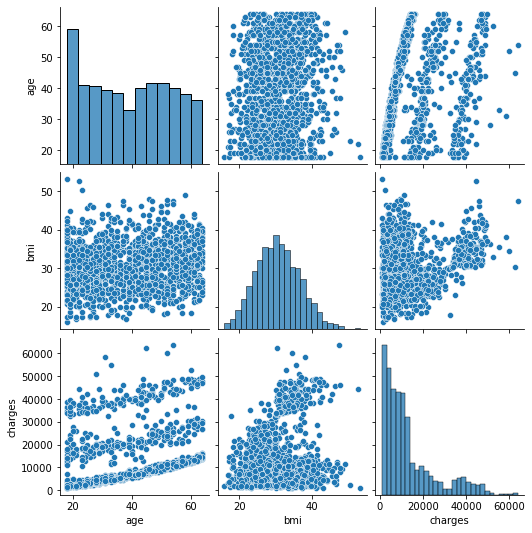

In [19]:
sns.pairplot(df[numerical_columns])
plt.show()

<AxesSubplot:xlabel='age'>

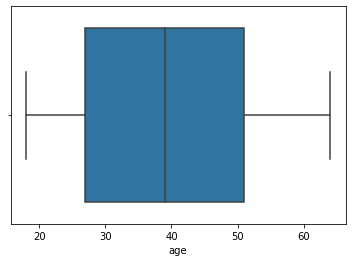

In [20]:
df.drop_duplicates(inplace=True)
sns.boxplot(df['age'])

As we can see there are no outliers in age column

<AxesSubplot:xlabel='bmi'>

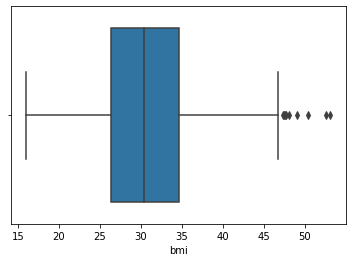

In [21]:
sns.boxplot(df['bmi'])

Due to the presence of outliers present in bmi column we need to treat the outliers by replacing the values with mean 
as the bmi column consists of continuous data.

In [22]:
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
upper_array = np.where(df['bmi'] >= upper)[0]
lower_array = np.where(df['bmi'] <= lower)[0]
df.drop(index=upper_array, inplace=True)
df.drop(index=lower_array, inplace=True)
print("New Shape: ", df.shape)

New Shape:  (1328, 7)


# Feature Selection

In [23]:
df.corr()

,age,bmi,children,charges
age,1.000000,0.102028,0.044164,0.298232
bmi,0.102028,1.000000,0.013577,0.194357
children,0.044164,0.013577,1.000000,0.069678
charges,0.298232,0.194357,0.069678,1.000000


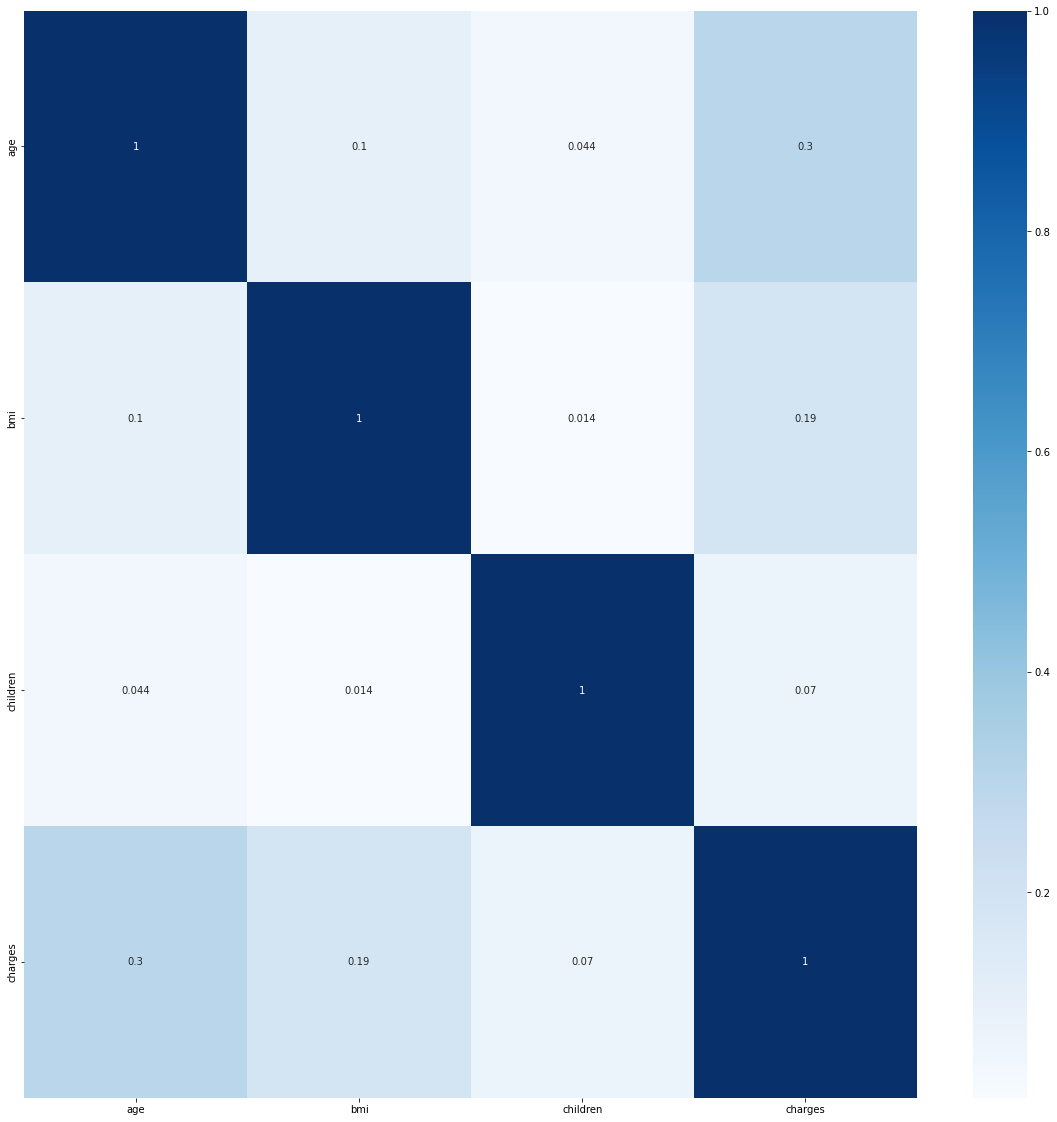

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
#get correlations of each features in dataset
corrmat = df.corr()
top_corr_features = corrmat.index
plt.figure(figsize=(20,20))
#plot heat map
g=sns.heatmap(df[top_corr_features].corr(),annot=True,cmap="Blues")

# Data Pre-Processing

Encoding the categorical features

In [25]:
# encoding sex column
df.replace({'sex':{'male':0,'female':1}}, inplace=True)

In [26]:
# encoding 'smoker' column
df.replace({'smoker':{'yes':0,'no':1}}, inplace=True)

In [27]:
# encoding 'region' column
df.replace({'region':{'southeast':0,'southwest':1,'northeast':2,'northwest':3}}, inplace=True)

Splitting the Features and Target

In [28]:
X = df.drop(columns='charges', axis=1)
Y = df['charges']

In [29]:
print(X)

      age  sex     bmi  children  smoker  region
0      19    1  27.900         0       0       1
1      18    0  33.770         1       1       0
2      28    0  33.000         3       1       0
3      33    0  22.705         0       1       3
4      32    0  28.880         0       1       3
...   ...  ...     ...       ...     ...     ...
1333   50    0  30.970         3       1       3
1334   18    1  31.920         0       1       2
1335   18    1  36.850         0       1       0
1336   21    1  25.800         0       1       1
1337   61    1  29.070         0       0       3

[1328 rows x 6 columns]


In [30]:
print(Y)

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1328, dtype: float64


# Model Training and Model Evaluation

Linear regression

In [31]:
from sklearn.linear_model import LinearRegression,Lasso
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
l1=[]
l2=[]
l3=[]
cvs=0
for i in range(40,50):
    X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=i)
    lrmodel=LinearRegression()
    lrmodel.fit(X_train,Y_train)
    l1.append(lrmodel.score(X_train,Y_train))
    l2.append(lrmodel.score(X_test,Y_test))
    cvs=(cross_val_score(lrmodel,X,Y,cv=5,)).mean()
    l3.append(cvs)
    
    df1=pd.DataFrame({'train acc':l1,'test acc':l2,'cvs':l3})
df1

,train acc,test acc,cvs
0,0.749442,0.752231,0.747416
1,0.757337,0.688988,0.747416
2,0.749801,0.751920,0.747416
3,0.751376,0.745514,0.747416
4,0.749523,0.752266,0.747416
5,0.752923,0.738961,0.747416
6,0.744152,0.775637,0.747416
7,0.758454,0.716673,0.747416
8,0.752479,0.738849,0.747416
9,0.753883,0.732819,0.747416


In [32]:
Y_predict=lrmodel.predict(X_test)
import math
print(mean_squared_error(Y_test,Y_predict))
print(math.sqrt(mean_squared_error(Y_test,Y_predict)))

36681217.10774677
6056.5020521540955


In [33]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
lrmodel=LinearRegression()
lrmodel.fit(X_train,Y_train)
print(lrmodel.score(X_train,Y_train))
print(lrmodel.score(X_test,Y_test))
print(cross_val_score(lrmodel,X,Y,cv=5,).mean())

0.7498007384954299
0.7519204822398459
0.7474163302711657


SVR

In [34]:
from sklearn.metrics import r2_score
svrmodel=SVR()
svrmodel.fit(X_train,Y_train)
Y_predtrain1=svrmodel.predict(X_train)
Y_predtest1=svrmodel.predict(X_test)
print(r2_score(Y_train,Y_predtrain1))
print(r2_score(Y_test,Y_predtest1))
print(cross_val_score(svrmodel,X,Y,cv=5,).mean())

-0.10166698434875432
-0.10316757038753233
-0.10583480976961032


In [35]:
Y_predtrain1=svrmodel.predict(X_test)
import math
print(mean_squared_error(Y_test,Y_predtrain1))
print(math.sqrt(mean_squared_error(Y_test,Y_predtrain1)))

157260662.18404493
12540.361325896672


Random Forest

In [36]:
rfmodel=RandomForestRegressor(random_state=42)
rfmodel.fit(X_train,Y_train)
Y_predtrain2=rfmodel.predict(X_train)
Y_predtest2=rfmodel.predict(X_test)
print(r2_score(Y_train,Y_predtrain2))
print(r2_score(Y_test,Y_predtest2))
print(cross_val_score(rfmodel,X,Y,cv=5,).mean())
from sklearn.model_selection import GridSearchCV
estimator=RandomForestRegressor(random_state=34)
param_grid={'n_estimators':[10,40,50,98,100,120,150]}
grid=GridSearchCV(estimator,param_grid,scoring="r2",cv=5)
grid.fit(X_train,Y_train)
print(grid.best_params_)
rfmodel=RandomForestRegressor(random_state=34,n_estimators=120)
rfmodel.fit(X_train,Y_train)
Y_predtrain2=rfmodel.predict(X_train)
Y_predtest2=rfmodel.predict(X_test)
print(r2_score(Y_train,Y_predtrain2))
print(r2_score(Y_test,Y_predtest2))
print(cross_val_score(rfmodel,X,Y,cv=5,).mean())

0.9773907126956217
0.8146195921997015
0.8348220656750277
{'n_estimators': 150}
0.9759631269637226
0.8154882435760746
0.837165427867132


In [37]:
Y_predtrain2=rfmodel.predict(X_test)
import math
print(mean_squared_error(Y_test,Y_predtrain2))
print(math.sqrt(mean_squared_error(Y_test,Y_predtrain2)))

26302840.81481339
5128.629525985806


Gradient Boost

In [38]:
gbmodel=GradientBoostingRegressor()
gbmodel.fit(X_train,Y_train)
Y_predtrain3=gbmodel.predict(X_train)
Y_predtest3=gbmodel.predict(X_test)
print(r2_score(Y_train,Y_predtrain3))
print(r2_score(Y_test,Y_predtest3))
print(cross_val_score(gbmodel,X,Y,cv=5,).mean())
from sklearn.model_selection import GridSearchCV
estimator=GradientBoostingRegressor()
param_grid={'n_estimators':[10,15,19,20,21,50],'learning_rate':[0.1,0.19,0.2,0.21,0.8,1]}
grid=GridSearchCV(estimator,param_grid,scoring="r2",cv=5)
grid.fit(X_train,Y_train)
print(grid.best_params_)
gbmodel=GradientBoostingRegressor(n_estimators=19,learning_rate=0.2)
gbmodel.fit(X_train,Y_train)
Y_predtrain3=gbmodel.predict(X_train)
Y_predtest3=gbmodel.predict(X_test)
print(r2_score(Y_train,Y_predtrain3))
print(r2_score(Y_test,Y_predtest3))
print(cross_val_score(gbmodel,X,Y,cv=5,).mean())

0.906927897856119
0.8479416859765252
0.854255490138704
{'learning_rate': 0.1, 'n_estimators': 50}
0.8841345058505506
0.8562633123247191
0.8601291820907271


In [39]:
Y_predtrain3=gbmodel.predict(X_test)
import math
print(mean_squared_error(Y_test,Y_predtrain3))
print(math.sqrt(mean_squared_error(Y_test,Y_predtrain3)))

20490202.29629784
4526.610464386994
